In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, log_loss, roc_auc_score, f1_score, recall_score, roc_curve
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

In [20]:
# data loaded via UCI API (see fetch_ucirepo below)
# if you want to load from local CSV instead, uncomment below and comment out the fetch_ucirepo line
# data = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
heart_failure = fetch_ucirepo(id=519)

data = heart_failure.data.features.copy().join(heart_failure.data.targets)
print(data.info())

X_raw = heart_failure.data.features
y = heart_failure.data.targets.squeeze()

X_train_raw, X_test_raw, y_train_val, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  death_event               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB
None


In [21]:
# correlation heatmap to check for multicollinearity and feature importance
train_data = X_train_raw.copy().join(y_train_val)
train_correlation = train_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(train_correlation, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, cbar_kws={'shrink': 0.75})
plt.title('Correlation Matrix of Heart Failure Clinical Records')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.close()

In [22]:
# keep only features most correlated with the target
features = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'high_blood_pressure']

X_train_val = X_train_raw[features]
X_test = X_test_raw[features]

scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)  # scale only on training data
X_test = scaler.transform(X_test)                # apply the same scaler to test

In [23]:
# hyperparameter search: use AUC, not accuracy, because the data is imbalanced
lr_params = [
    {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']},
    {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1'], 'solver': ['liblinear']},
]
lr_model = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'), lr_params,
                        cv=5, scoring='roc_auc').fit(X_train_val, y_train_val).best_estimator_

In [24]:
svc_params = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': [0.001, 0.01, 0.1, 'scale', 'auto'],
}
svc_model = GridSearchCV(SVC(probability=True, class_weight='balanced'), svc_params, cv=5, scoring='roc_auc').fit(X_train_val, y_train_val).best_estimator_

In [25]:
# 4-fold cross-validation
kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

results = {
    'lr':  {'train_loss': [], 'val_loss': [], 'auc': [], 'f1': [], 'recall': []},
    'svc': {'train_loss': [], 'val_loss': [], 'auc': [], 'f1': [], 'recall': []},
}

In [26]:
for train_idx, val_idx in kf.split(X_train_val, y_train_val):
    X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
    y_train, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]

    for name, model in [('lr', lr_model), ('svc', svc_model)]:
        model.fit(X_train, y_train)
        proba_train = model.predict_proba(X_train)
        proba_val   = model.predict_proba(X_val)
        y_pred      = model.predict(X_val)

        results[name]['train_loss'].append(log_loss(y_train, proba_train))
        results[name]['val_loss'].append(log_loss(y_val, proba_val))
        results[name]['auc'].append(roc_auc_score(y_val, proba_val[:, 1]))
        results[name]['f1'].append(f1_score(y_val, y_pred))
        results[name]['recall'].append(recall_score(y_val, y_pred))

In [27]:
# final evaluation on held-out test set
for model in [lr_model, svc_model]:
    model.fit(X_train_val, y_train_val)

In [28]:
def test_metrics(model):
    proba = model.predict_proba(X_test)
    y_pred = model.predict(X_test)
    return {
        'proba':       proba[:, 1],   
        'y_pred':      y_pred,        
        'test_loss':   log_loss(y_test, proba),
        'test_auc':    roc_auc_score(y_test, proba[:, 1]),
        'test_f1':     f1_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
    }

In [29]:
lr_test  = test_metrics(lr_model)
svc_test = test_metrics(svc_model)

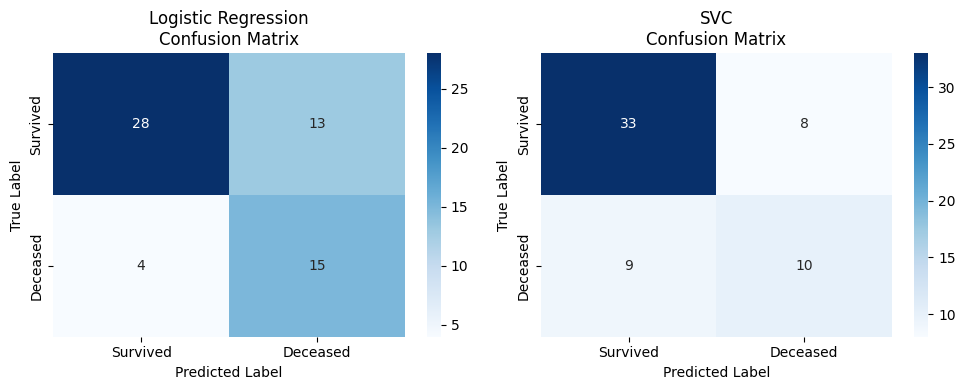

Saved: confusion_matrices.png


In [30]:
#confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, [('Logistic Regression', lr_test), ('SVC', svc_test)]):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Survived', 'Deceased'],
                yticklabels=['Survived', 'Deceased'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()
print("Saved: confusion_matrices.png")

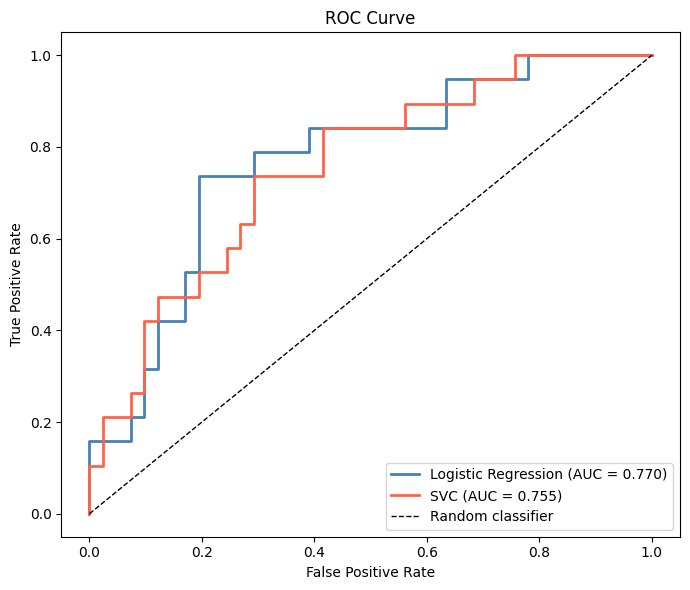

Saved: roc_curve.png


In [31]:
# ROC curves
plt.figure(figsize=(7, 6))
for name, res, color in [('Logistic Regression', lr_test, 'steelblue'), ('SVC', svc_test, 'tomato')]:
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {res['test_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()
print("Saved: roc_curve.png")

In [32]:
# print results
def avg(lst): return np.mean(lst)

print(f"{'Metric':<30}{'Logistic Regression':<22}{'SVC'}")
print(f"{'Train Log Loss':<30}{avg(results['lr']['train_loss']):<22.4f}{avg(results['svc']['train_loss']):.4f}")
print(f"{'Val Log Loss':<30}{avg(results['lr']['val_loss']):<22.4f}{avg(results['svc']['val_loss']):.4f}")
print(f"{'Val AUC-ROC':<30}{avg(results['lr']['auc']):<22.4f}{avg(results['svc']['auc']):.4f}")
print(f"{'Val F1 (deceased)':<30}{avg(results['lr']['f1']):<22.4f}{avg(results['svc']['f1']):.4f}")
print(f"{'Val Recall (deceased)':<30}{avg(results['lr']['recall']):<22.4f}{avg(results['svc']['recall']):.4f}")
print(f"{'Test Log Loss':<30}{lr_test['test_loss']:<22.4f}{svc_test['test_loss']:.4f}")
print(f"{'Test AUC-ROC':<30}{lr_test['test_auc']:<22.4f}{svc_test['test_auc']:.4f}")
print(f"{'Test F1 (deceased)':<30}{lr_test['test_f1']:<22.4f}{svc_test['test_f1']:.4f}")
print(f"{'Test Recall (deceased)':<30}{lr_test['test_recall']:<22.4f}{svc_test['test_recall']:.4f}")

Metric                        Logistic Regression   SVC
Train Log Loss                0.6043                0.5275
Val Log Loss                  0.6251                0.5275
Val AUC-ROC                   0.7773                0.7991
Val F1 (deceased)             0.6367                0.6649
Val Recall (deceased)         0.7401                0.7138
Test Log Loss                 0.5949                0.5408
Test AUC-ROC                  0.7702                0.7548
Test F1 (deceased)            0.6383                0.5405
Test Recall (deceased)        0.7895                0.5263


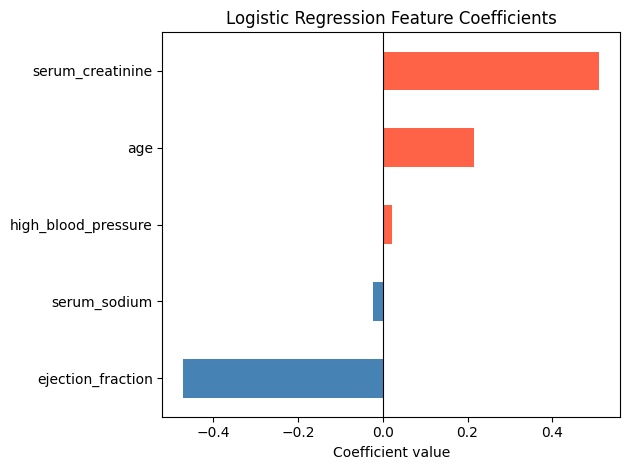

In [33]:
coefficients = pd.Series(lr_model.coef_[0], index=['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'high_blood_pressure'])
coefficients.sort_values().plot(kind='barh', color=['tomato' if c > 0 else 'steelblue' for c in coefficients.sort_values()])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=300)
plt.show()